#CELL 1
# Module 2.3 — Employee Segmentation

This notebook groups employees into workforce segments using KMeans clustering.

The number of clusters is selected using silhouette score, while inertia is shown
to illustrate the elbow method.

In [1]:
#CELL 2
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load import load_raw_ibm_hr
from src.data.preprocess import clean_hr_data
from src.modeling.segmentation import (
    assign_cluster,
    fit_kmeans,
    prepare_segmentation_features,
    save_segmentation_model,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

Project root: c:\Users\Anvesha Garg\Desktop\workforce360\workforce360


In [2]:
#CELL 3
raw_df = load_raw_ibm_hr()
clean_df = clean_hr_data(raw_df)

X, features = prepare_segmentation_features(clean_df)

print(f"Employees: {len(X):,}")
print(f"Features used: {features}")

X.head()

Employees: 1,470
Features used: ['age', 'monthly_income', 'years_at_company', 'total_working_years', 'years_since_promotion', 'job_satisfaction', 'overtime_flag']


,age,monthly_income,years_at_company,total_working_years,years_since_promotion,job_satisfaction,overtime_flag
0,41,5993,6,8,0,4,1
1,49,5130,10,10,1,2,0
2,37,2090,0,7,0,3,1
3,33,2909,8,8,3,3,1
4,27,3468,2,6,2,2,0


In [3]:
#CELL 4
model, evaluation_df, silhouette_scores = fit_kmeans(
    X=X,
    k_range=(3, 6),
)

evaluation_df

,k,inertia,silhouette_score
0,3,6104.962058,0.264604
1,4,5418.612368,0.269609
2,5,4759.257243,0.229581
3,6,4325.291638,0.230269


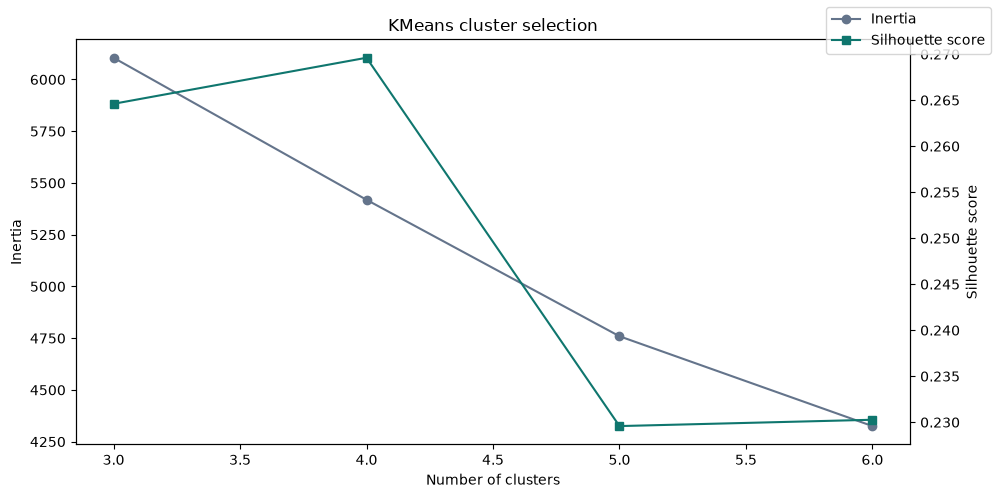

In [4]:
#CELL 5
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    evaluation_df["k"],
    evaluation_df["inertia"],
    marker="o",
    label="Inertia",
    color="#64748b",
)

ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Inertia")
ax1.set_title("KMeans cluster selection")

ax2 = ax1.twinx()

ax2.plot(
    evaluation_df["k"],
    evaluation_df["silhouette_score"],
    marker="s",
    color="#0f766e",
    label="Silhouette score",
)

ax2.set_ylabel("Silhouette score")

fig.legend(loc="upper right")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "segmentation_cluster_selection.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [5]:
#CELL 6
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cluster_labels = model.predict(X_scaled)

segmented_df = clean_df.copy()
segmented_df["cluster"] = cluster_labels

segmented_df["cluster"].value_counts().sort_index()

cluster
0    167
1    831
2    340
3    132
Name: count, dtype: int64

In [6]:
#CELL 7
cluster_profile = (
    segmented_df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,age,monthly_income,years_at_company,total_working_years,years_since_promotion,job_satisfaction,overtime_flag
cluster,,,,,,,
0,49.59,13542.62,6.80,23.16,1.60,2.68,0.24
1,33.98,4657.82,5.44,8.04,1.53,2.72,0.00
2,34.91,4751.98,5.38,8.52,1.57,2.81,1.00
3,44.61,13722.50,21.36,23.71,8.65,2.67,0.27


In [7]:
#CELL 8
cluster_attrition = (
    segmented_df
    .groupby("cluster")["attrition_flag"]
    .mean()
    .mul(100)
    .round(2)
    .rename("Attrition rate (%)")
)

cluster_summary = cluster_profile.join(cluster_attrition)

cluster_summary

,age,monthly_income,years_at_company,total_working_years,years_since_promotion,job_satisfaction,overtime_flag,Attrition rate (%)
cluster,,,,,,,,
0,49.59,13542.62,6.80,23.16,1.60,2.68,0.24,5.39
1,33.98,4657.82,5.44,8.04,1.53,2.72,0.00,11.43
2,34.91,4751.98,5.38,8.52,1.57,2.81,1.00,34.12
3,44.61,13722.50,21.36,23.71,8.65,2.67,0.27,12.88


#CELL 9
## Cluster interpretation

Use the cluster profile table above to assign each segment a practical HR label.

For example, clusters may represent groups such as:

- Early-career employees
- Experienced stable employees
- High-income senior employees
- High-overtime employees
- Recently promoted employees
- Lower-satisfaction employees

The exact names should reflect the actual averages in the table above.

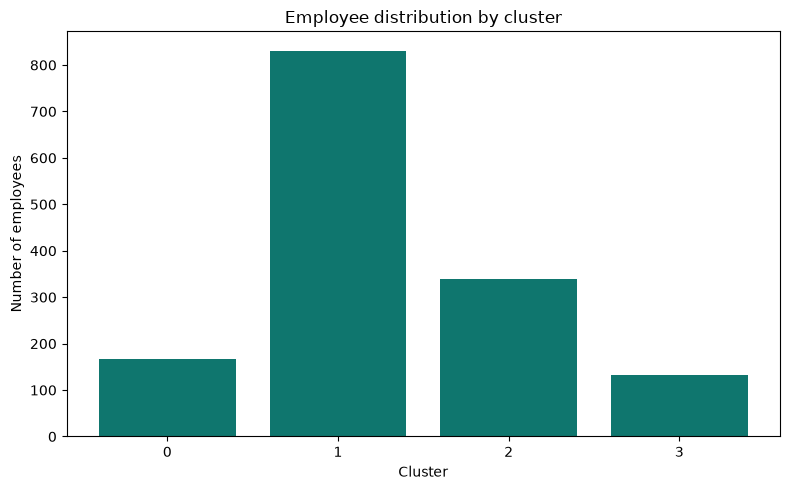

In [8]:
#CELL 10
cluster_sizes = segmented_df["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values,
    color="#0f766e",
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Number of employees")
ax.set_title("Employee distribution by cluster")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "segmentation_cluster_sizes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [9]:
#CELL 11
model.scaler = scaler

model_path = save_segmentation_model(
    model=model,
    scaler=scaler,
    features=features,
)

print(f"Saved segmentation model to: {model_path}")

Saved segmentation model to: models\segmentation_model.joblib


In [10]:
#CELL 12
cluster_summary.to_csv(
    ROOT / "reports" / "segmentation_cluster_profiles.csv",
)

print("Saved:")
print(ROOT / "reports" / "segmentation_cluster_profiles.csv")

Saved:
c:\Users\Anvesha Garg\Desktop\workforce360\workforce360\reports\segmentation_cluster_profiles.csv


#CELL 13
## Results

- KMeans segmented employees into meaningful workforce groups.
- The final number of clusters was selected using silhouette score.
- Cluster profiles summarize average age, income, tenure, promotion gap, satisfaction, and overtime.
- The segmentation model and scaler were saved for future employee assignments.